In [2]:
# import geopandas
from osgeo import gdal
import struct
import folium
import rasterio
import rasterio.plot
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
path = "/home/emmaf/Documents/Data269/SewerRepairProject/Environment_Tree_Canopy_Rasters/Tree_Canopy_2023_rasters.gdb"

ds = gdal.Open(path,gdal.GA_ReadOnly)
print(ds)

aug_path = f"OpenFileGDB:{path}:tcdm2023_reclass"
ds2 = gdal.Open(aug_path,gdal.GA_ReadOnly)
print(ds2)

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7d51d2558ae0> >
<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7d51d405eeb0> >


In [18]:


print("Projection: ", ds2.GetProjection())  # get projection
print("Columns:", ds2.RasterXSize)  # number of columns
print("Rows:", ds2.RasterYSize)  # number of rows
print("Band count:", ds2.RasterCount)  # number of bands

print ("Blocks per Row:", (ds2.RasterXSize/128))
print ("Blocks per Column:", (ds2.RasterYSize/128))


Projection:  COMPD_CS["NAD83 / Maryland (ftUS) + NAVD88 height (ftUS)",PROJCS["NAD83 / Maryland (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",37.6666666666667],PARAMETER["central_meridian",-77],PARAMETER["standard_parallel_1",38.3],PARAMETER["standard_parallel_2",39.45],PARAMETER["false_easting",1312333.33333333],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","2248"]],VERT_CS["NAVD88 height (ftUS)",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["US survey foot",0.304800609601219],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","6360"]]]
Columns: 60337
Rows: 50862
Band count: 1
Blocks per Row: 471.3828125
Blo

In [25]:

lyr = ds2.GetLayerByName("tcdm2023_reclass")
print("Layer by name: ", lyr)

lyr = ds2.GetLayerByIndex(0)
print("Layer by index: ", lyr)

subs = ds2.GetSubDatasets()
print("Sub datasets: ", subs)


# for i in range(1,ds2.RasterCount+1):
#     print(ds2.GetRasterBand(i))

band = ds2.GetRasterBand(1)
print(band)


Layer by name:  <osgeo.ogr.Layer; proxy of <Swig Object of type 'OGRLayerShadow *' at 0x7d51d0362460> >
Layer by index:  <osgeo.ogr.Layer; proxy of <Swig Object of type 'OGRLayerShadow *' at 0x7d51d0aec750> >
Sub datasets:  []
<osgeo.gdal.Band; proxy of <Swig Object of type 'GDALRasterBandShadow *' at 0x7d51d0aef6f0> >


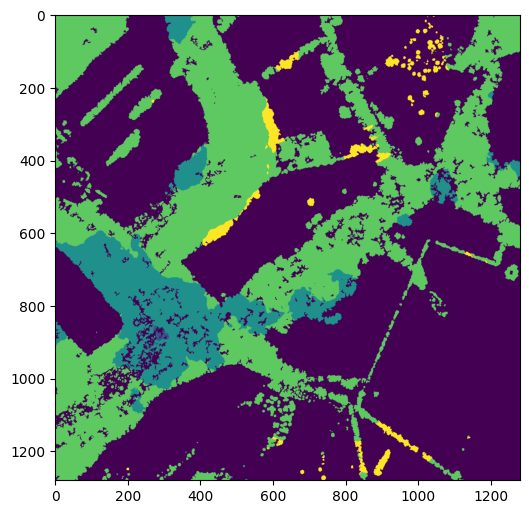

In [32]:
# The grid of raster values can be accessed as a numpy array and plotted:

window = rasterio.windows.Window(12800,12800,1280,1280)

raster_path = "/home/emmaf/Documents/Data269/SewerRepairProject/Exported_TreeCanopyRasters/"

with rasterio.open(f"{raster_path}/tcdm2023_reclass.tif") as src:
   # window = src.block_window(1, 100, 100)
   subset = src.read(1,window=window)

plt.figure(figsize=(6,8.5))
plt.imshow(subset)

#    oviews = src.overviews(1) # list of overviews from biggest to smallest
#    oview = oviews[-1] # let's look at the smallest thumbnail
#    print('Decimation factor= {}'.format(oview))
#    # NOTE this is using a 'decimated read' (http://rasterio.readthedocs.io/en/latest/topics/resampling.html)
#    thumbnail = src.read(1, out_shape=(1, int(src.height // oview), int(src.width // oview)))

# print('array type: ',type(thumbnail))
# print(thumbnail)

# plt.imshow(thumbnail)
# plt.colorbar()
# plt.title('Overview - Band 4 {}'.format(thumbnail.shape))
# plt.xlabel('Column #')
# plt.ylabel('Row #')